# Laboratorio # 5

## Sección inicial

Empezaremos importando todas las librerías necesarias y también definiremo todas las variables y funciones que serán útiles para realizar operaciones sobre el dataset.

In [241]:
import re
import pandas as pd
import nltk
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Embedding
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from textblob import TextBlob

### Variables importantes

In [220]:
nltk.download('stopwords') #Descargar las stopwords de nltk

# Stopwords completas de NLTK + sklearn
stop_words = set(stopwords.words('english')).union(ENGLISH_STOP_WORDS)

# Lista extra de palabras comunes, incluyendo preposiciones, pronombres y conjunciones más frecuentes
extra_words = {
    "like", "im", "amp", "dont", "ive", "youre", "cant", "didnt", "youtube",
    "i", "me", "my", "we", "us", "our", "you", "your", "he", "him", "his",
    "she", "her", "it", "its", "they", "them", "their",
    "a", "an", "the", "and", "but", "or", "nor", "for", "so", "yet", "at",
    "by", "from", "in", "into", "on", "onto", "of", "to", "with", "about",
    "as", "like", "over", "under", "between", "among", "through", "during",
    "before", "after", "since", "until", "while", "although", "because",
    "if", "than", "that", "which", "who", "whom", "whose", "when", "where", "why", "how"
} #Agregamos más stopwords
stop_words.update(extra_words)


allowed_numbers = {"1945", "911", "2008", "2014", "1980", "2013", "2016", "2011"} # Números permitidos en cada tweet



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ppguz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Funciones importantes 

In [221]:
def convert_to_lower(word): #Convierte a minúsculas
    return word.lower()

def remove_special_characters(word): #Remueve comillas. arrobas y hashtagas
    return word.replace("#", "").replace("@", "").replace("'", "")

def remove_url(word): #Busca urls y las remueve
    text = re.sub(r'http\S+|www\S+|https\S+', '', word)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_emojis(word): #Busca emojis y los borra
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F" 
        "\U0001F300-\U0001F5FF" 
        "\U0001F680-\U0001F6FF" 
        "\U0001F1E0-\U0001F1FF"  
        "\U00002700-\U000027BF"  
        "\U0001F900-\U0001F9FF"  
        "\U00002600-\U000026FF"  
        "\U00002B00-\U00002BFF" 
        "\U0001FA70-\U0001FAFF" 
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', word).strip()

# Función para limpiar el texto
def clean_text(text):
    # Quitar puntuación
    text = re.sub(r'[^\w\s]', '', str(text))
    # Tokenizar y eliminar stopwords
    tokens = [word for word in text.split() if word.lower() not in stop_words]
    return " ".join(tokens)


def extract_numbers(text):
    return re.findall(r'\d+', str(text)) #busca y extrae números en el dataset

def count_words(dataset, column): #Esta función cuenta las palabras en cada tweet
    all_words = ''
    for i in dataset[column]:
        all_words = all_words + i + ' '

    all_words = all_words.split()

    frequency = Counter(all_words)

    print("{:<10} {:<10}".format("Palabra", "Frecuencia"))
    print("-" * 20)
    for palabra, freq in frequency.most_common():
        print("{:<10} {:<10}".format(palabra, freq))

def remove_unwanted_numbers(text): #Remueve números que no son permitidos en los tweets
    return re.sub(r'\b(?!' + '|'.join(allowed_numbers) + r')\d+\b', '', str(text))

def get_words(text_series): #Obtener y separar palabras por tweet
    words = []
    for text in text_series:
        words.extend(str(text).split())  
    return words

# Función para crear nube de palabras
def plot_wordcloud(counter, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(counter)
    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

# Función para crear histograma de top N palabras
def plot_histogram(counter, title, top_n=20):
    most_common = counter.most_common(top_n)
    words, counts = zip(*most_common)
    plt.figure(figsize=(12,6))
    plt.bar(words, counts, color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.title(title, fontsize=20)
    plt.show()

## Limpieza

Ahora que ya definimos las herramientas que nos ayudarán a realizar operaciones sobre el dataset, vamos a leerlo y hacer operaciones de limpieza sobre el. Vamos a empezar con una pequeña exploración inicial sobre los conjuntos de datos.

In [222]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [223]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


Arriba se observan las 5 primeras filas del conjunto de prueba, vemos que hay caracteres especiales, signos de puntación, números, etc. 

In [224]:
test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


El conjunto de prueba tiene caracteres especiales, letras mayúsculas y minúsculas, etc al igual que el conjunto de entrenamiento, por lo tanto vamos a tener que realizar operaciones de limpieza sobre estos 2 conjuntos. 

Vamos a empezar a limpiar el dataset. Primero vamos a convertir todo el texto a minúscula, eliminar los caracteres especiales, urls y emojis

In [225]:
train['text'] = train['text'].astype(str).apply(convert_to_lower)
train['text'] = train['text'].astype(str).apply(remove_special_characters)
train['text'] = train['text'].astype(str).apply(remove_url)
train['text'] = train['text'].astype(str).apply(remove_emojis)
test['text'] = test['text'].astype(str).apply(convert_to_lower)
test['text'] = test['text'].astype(str).apply(remove_special_characters)
test['text'] = test['text'].astype(str).apply(remove_url)
test['text'] = test['text'].astype(str).apply(remove_emojis)

train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,our deeds are the reason of this earthquake ma...,1
1,4,NaN,NaN,forest fire near la ronge sask. canada,1
2,5,NaN,NaN,all residents asked to shelter in place are be...,1
3,6,NaN,NaN,"13,000 people receive wildfires evacuation ord...",1
4,7,NaN,NaN,just got sent this photo from ruby alaska as s...,1


Se puede observar que limpiamos exitosamente el conjunto de entrenamiento y prueba. Ahora también vamos a quitar los signos de puntuación

In [226]:
train["text"] = train["text"].str.replace(r'[^\w\s]', '', regex=True)

test["text"] = test["text"].str.replace(r'[^\w\s]', '', regex=True)

Seguimos limpiando, ahora vamos a quitar los artículos, preposiciones y conjunciones

In [227]:
train["text"] = train["text"].apply(clean_text)
test["text"] = test["text"].apply(clean_text)

Ahora vamos a quitar los números, primero vamos a ver cuales eliminar, listando por los que mas aparecen


In [228]:
train_nums = train.copy()
train_nums["numbers"] = train_nums["text"].apply(extract_numbers)

test_nums = test.copy()
test_nums["numbers"] = test_nums["text"].apply(extract_numbers)

all_nums = pd.concat([train_nums[["numbers"]], test_nums[["numbers"]]], ignore_index=True)

all_nums = all_nums[all_nums["numbers"].map(len) > 0]

all_numbers_flat = np.concatenate(all_nums["numbers"].values)

summary = pd.Series(all_numbers_flat).value_counts().reset_index()
summary.columns = ["number", "count"]
summary


,number,count
0,2,377
1,3,264
2,4,227
3,1,225
4,5,197
...,...,...
790,2601,1
791,27001,1
792,645,1
793,32931,1


Sabiendo esto vamos a conservar los numeros 1945, 911, 2008, 2014, 1980, 2013, 2016, 2011  ya que son fechas importantes, ademas de que son numeros de telefono que pueden tener relacion con el analisis de sentimientos


In [229]:
train["text"] = train["text"].apply(remove_unwanted_numbers)
test["text"] = test["text"].apply(remove_unwanted_numbers)

test.head()

,id,keyword,location,text
0,0,NaN,NaN,happened terrible car crash
1,2,NaN,NaN,heard earthquake different cities stay safe
2,3,NaN,NaN,forest spot pond geese fleeing street save
3,9,NaN,NaN,apocalypse lighting spokane wildfires
4,11,NaN,NaN,typhoon soudelor kills china taiwan


In [230]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,deeds reason earthquake allah forgive,1
1,4,NaN,NaN,forest near la ronge sask canada,1
2,5,NaN,NaN,residents asked shelter place notified officer...,1
3,6,NaN,NaN,people receive wildfires evacuation orders ca...,1
4,7,NaN,NaN,got sent photo ruby alaska smoke wildfires pou...,1


## Análisis exploratorio

Vamos a empezar contando  las palabras más frecuentes en cada categoría. Primero vamos a empezar con los tweets que si hablan de desastres naturales

In [231]:

natural_disaters = train[train['target'] == 1]

count_words(natural_disaters, 'text')

Palabra    Frecuencia
--------------------
news       136       
disaster   117       
california 111       
suicide    110       
police     107       
people     105       
killed     93        
hiroshima  86        
storm      85        
crash      84        
fires      84        
families   81        
train      79        
emergency  76        
buildings  75        
bomb       74        
mh370      71        
nuclear    70        
attack     69        
video      69        
wildfire   69        
accident   66        
bombing    66        
northern   64        
burning    64        
dead       63        
pm         62        
legionnaires 62        
bomber     60        
homes      58        
car        57        
war        57        
new        56        
atomic     56        
obama      54        
fatal      54        
years      53        
collapse   51        
forest     50        
debris     50        
watch      50        
japan      49        
malaysia   49        
man      

Ahora vamos con los tweets que no son de desastres naturales

In [232]:
no_natural_disasters = train[train['target'] == 0]
count_words(no_natural_disasters, 'text')

Palabra    Frecuencia
--------------------
new        168       
body       112       
video      96        
people     91        
love       89        
know       85        
time       83        
got        83        
emergency  81        
day        78        
going      75        
want       67        
good       67        
think      66        
man        62        
world      62        
lol        61        
rt         60        
life       60        
u          59        
news       57        
burning    56        
really     55        
way        55        
need       55        
make       54        
work       54        
best       53        
let        52        
help       48        
say        48        
great      47        
wreck      47        
right      46        
feel       46        
black      46        
content    46        
hot        45        
look       44        
god        44        
fear       44        
read       42        
ass        42        
cross      

Hacer n-gramas podría ser útil pues podría darnos más contexto sobre lo que habla el tweet y ver si verdaderamente habla de un desastre natural pues puede que un tweet tenga la palabra "News" pero hable de una noticia de deportes en vez de un desastre natural, sin embargo viendo las palabras que se repiten en los tweets que no son de desastres y en los que si consideramos que no es necesario usarlos pues hay pocas palabras que tienen en común. 

Sabiendo esto vamos a graficar y a ver en una nube de palabras todas las que encontramos


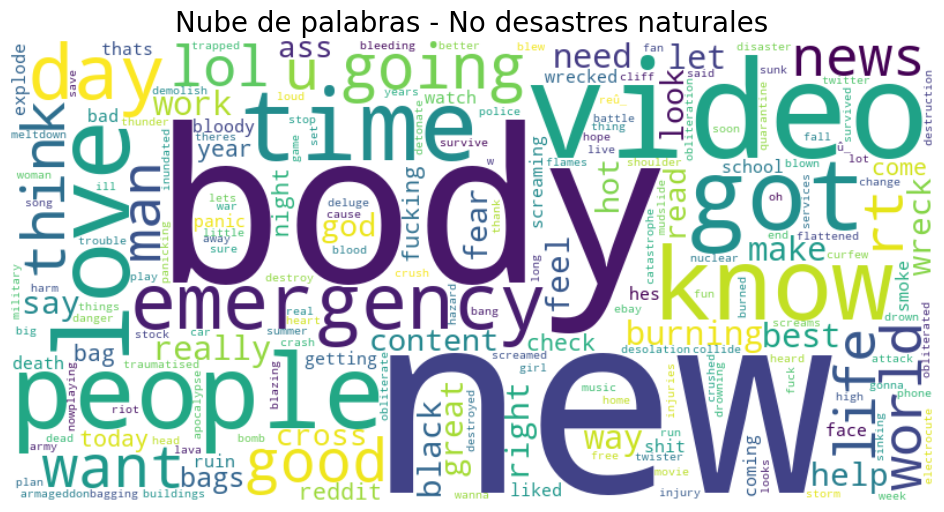

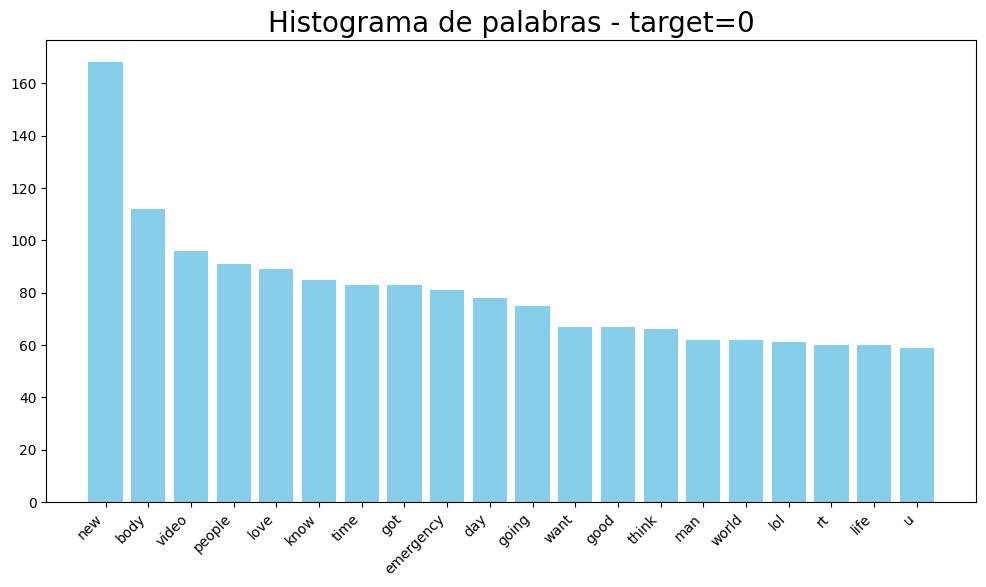

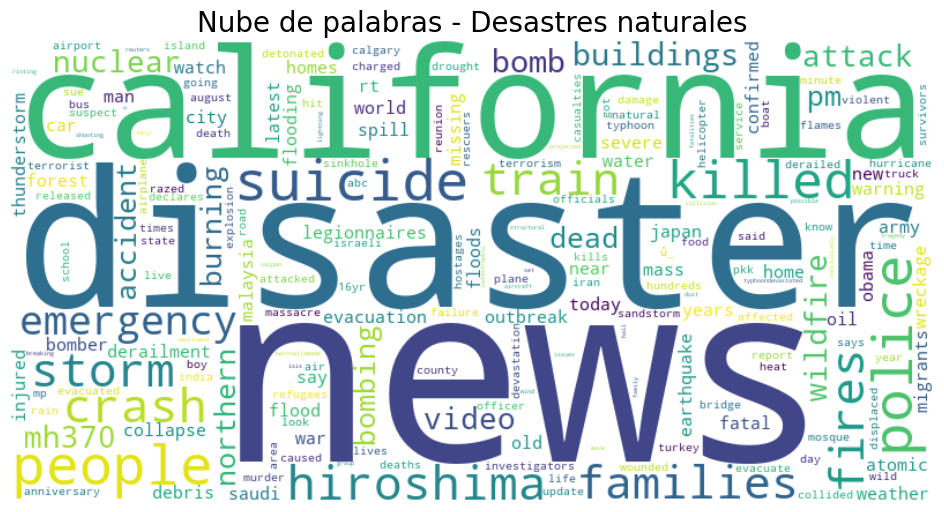

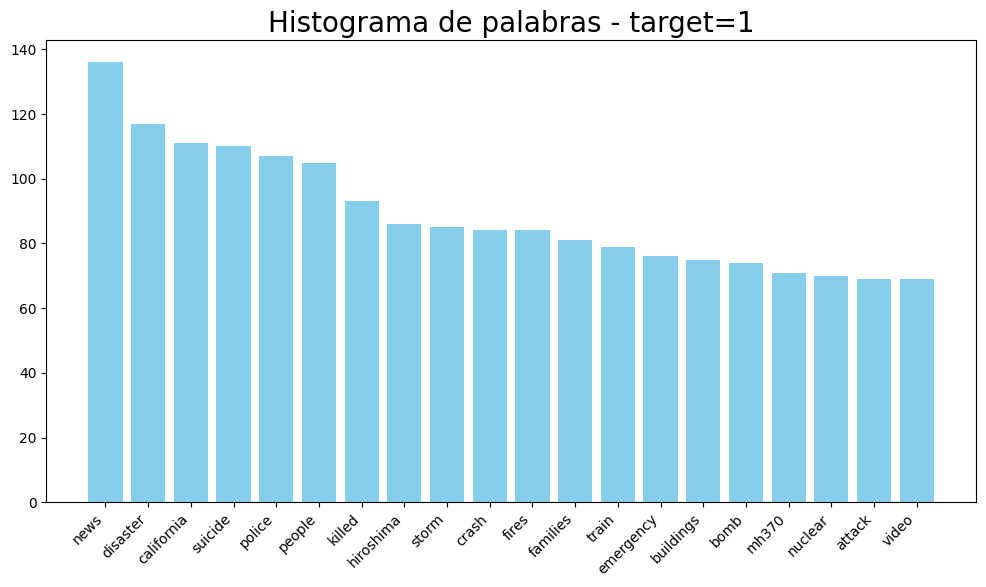

In [233]:
# Target = 0
plot_wordcloud(counter_0, "Nube de palabras - No desastres naturales")
plot_histogram(counter_0, "Histograma de palabras - target=0")

# Target = 1
plot_wordcloud(counter_1, "Nube de palabras - Desastres naturales")
plot_histogram(counter_1, "Histograma de palabras - target=1")

### Analisis

Podemos ver que las palabras que más nos aparecen en el lado cuando es catalogado como desastre real son mas que todo palabras como noticia, desastre, policia, personas, muertos, tormenta, choque , familias , emergencias, y ataque, y tambien video.

Esto se debe a que de las anteriores hace mucha referencia a elementos parte de un desastre , y las noticias es debido  a que normalmente suelen aparecer desastres en las noticias , debido a esto es que aparece clasificada aqui. Con respecto a video se debe a que hoy en dia es mas facil de ver videos de eventos en vivo y dadas las circunstancias es normal que un desastre se muestre en este formato.


En cambio en las que no son desastre suelen aparecer palabras menos asociadas a estos fenomenos, tales como amor, mundo, cuerpo, bueno, vida. Pero tambien suelen aparecer palabras que aparecen tambien etiquetadas como desastre tales como emergencia, noticias y video. 

Esto se debe a que las palabras noticias y video no son siempre de cosas malas sino tambien de eventos que suelen ocurrir con normalidad o eventos en tendencia que no necesariamente tengan que ver con desastres. Otra palabra que aprece bastante en ambos es "emergencia" y esto puede deberse a que no necesariamente pertenece a un contexto se desastres puede ser a cosas como tendencias y cosas que tengan que ver con la farandula que tampoco son desastres

## Modelos Clasificadores

Hay varios modelos que podríamos probar para clasificar los tweets pero consideramos que las mejores opcciones son las siguientes:

- Redes neuronales LSTM: estas redes se caracterizan por tener en cuenta datos anteriores y podría ayudarnos a que tenga en cuenta el contexto de palabras anteriores para determinar si el tweet en realidad habla de un desastre o no.
- Multi Layer Perceptron: el modelo tradicional de una red neuronal, puede ser útil para hallar relaciones no lineales en las palabras y ayudarnos a clasificar de mejor forma el tweet.
- Naive Bayes: es sencillo de entrenar, funciona bien con textos y gracias a que se basa en la probabilidad condicional puede ayudarnos a encontrar relaciones entre las palabras de los tweets.
- Regresión logística: también es útil para trabajar con textos y puede ser de ayuda para hallar relaciones lineales entre las palabras. 
- Random forest: al igual que el Naive bayes funciona bien con texto y gracias a su funcionamiento de usar muchos árboles de clasificación y ver cuál es la opción más votada por estos puede ser de ayuda para que cada árbol analize la importancia de cada una de las palabras para que un tweet sea clasificado en una de nustras categorías.

Antes de probar los modelos propuestos, vamos a convertir nuestra información en una estructura llamada bag of words, para usarla se hace lo siguiente:

- Ver las 5000 palabras más frecuentes en cada conjunto de datos y formar un vocabulario con ellas
- Convertir cada tweet un vector de tamaño 5000, cada valor del vector indica la frecuencia con la que se repite cada palabra del tweet. 

También vamos a crear otra estructura llamada Term Frequency – Inverse Document Frequency la cuál también convierte cada tweet en vecotres de tamaño del vocabulario que contiene todas las palabras que aparecen en los tweets pero a diferencia de la bolsa de palabras esta estrcutura pondera cada palabra según su importancia, si la palabra es muy común pesa menos y si es poco común pesa más.

Crearemos estas 2 estructuras pues vamos a entrenar nuestros modelos con ambas y queremos ver cuál de ellas nos da mejores resultados. 

In [ ]:
X = train["text"]   
y = train["target"] 


bow_vectorizer = CountVectorizer(max_features=5000, stop_words="english")  
X_bow = bow_vectorizer.fit_transform(X)

# TF-IDF (frecuencia ponderada)
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")  
X_tfidf = tfidf_vectorizer.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)

Vamos a empezar con el Naive Bayes y la regresión logística.

In [235]:
# Modelo 1: Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print("Naive Bayes con Bag of Words:\n", classification_report(y_test, y_pred_nb))

# Modelo 2: Regresión Logística
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
print("Regresión Logística con Bag of Words:\n", classification_report(y_test, y_pred_lr))


X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

nb.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb.predict(X_test_tfidf)
print("Naive Bayes con TF-IDF:\n", classification_report(y_test, y_pred_nb_tfidf))

Naive Bayes con Bag of Words:
               precision    recall  f1-score   support

           0       0.80      0.84      0.82       874
           1       0.76      0.71      0.74       649

    accuracy                           0.78      1523
   macro avg       0.78      0.78      0.78      1523
weighted avg       0.78      0.78      0.78      1523

Regresión Logística con Bag of Words:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83       874
           1       0.79      0.72      0.75       649

    accuracy                           0.80      1523
   macro avg       0.80      0.79      0.79      1523
weighted avg       0.80      0.80      0.80      1523

Naive Bayes con TF-IDF:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83       874
           1       0.80      0.68      0.74       649

    accuracy                           0.79      1523
   macro avg       0.79      0.78

Ambos tuvieron un buen rendimiento con ambas estrcuturas de datos (accuracy mayor a 0.75) y además tardaron poco tiempo en ejecutarse. Ahora vamos con el random forest.

In [236]:
# Random Forest con Bag of Words
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest con Bag of Words:\n", classification_report(y_test, y_pred_rf))

# Random Forest con TF-IDF
rf.fit(X_train_tfidf, y_train)
y_pred_rf_tfidf = rf.predict(X_test_tfidf)
print("Random Forest con TF-IDF:\n", classification_report(y_test, y_pred_rf_tfidf))

Random Forest con Bag of Words:
               precision    recall  f1-score   support

           0       0.78      0.79      0.79       874
           1       0.71      0.69      0.70       649

    accuracy                           0.75      1523
   macro avg       0.75      0.74      0.74      1523
weighted avg       0.75      0.75      0.75      1523

Random Forest con TF-IDF:
               precision    recall  f1-score   support

           0       0.78      0.85      0.81       874
           1       0.77      0.68      0.72       649

    accuracy                           0.78      1523
   macro avg       0.77      0.76      0.77      1523
weighted avg       0.78      0.78      0.77      1523



Tuvo un rendimiento similar a los modelos anteriores pero tardo en entrenarse

Ahora usaremos redes neuronales con LSTM y con MLP

### MLP

Para este multilayer perceptron usaremos:

- Una primera capa con función de activación relu y 128 neuronas
- Vamos a eliminar la mitad de estas neuronas aleatoriamente en cada época para evitar overfitting
- Luego una capa de 64 neuronas con relu y tabién con un dropout del 50%
- Finalmente la salida tendrá una activación sigmoide

In [248]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_train = tfidf.fit_transform(X_train_text).toarray()
X_test  = tfidf.transform(X_test_text).toarray()

# Modelo
mlp = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
mlp.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])

# Early stopping para frenar cuando empiece a sobreajustar
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

mlp.fit(
    X_train, y_train,
    epochs=20, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[es],
    verbose=1
)


Epoch 1/20


c:\Users\ppguz\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5810 - loss: 0.6707 - val_accuracy: 0.8122 - val_loss: 0.4557
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8367 - loss: 0.3967 - val_accuracy: 0.8148 - val_loss: 0.4484
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8870 - loss: 0.2873 - val_accuracy: 0.7978 - val_loss: 0.4851
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9211 - loss: 0.2189 - val_accuracy: 0.7899 - val_loss: 0.5474


Con 4 épocas el modelo alcanzo un buen accuracy en pruebas aunque baja un poco con el modelo de validación, la pérdidas también es más grande, esto puede indicarnos que hay un poco de overfitting a pesar de que el modelo tiene varias capas dropout, por esa razón es buena idea solamente usar 30 épocas para entrenar pues se obtiene un accuracy aceptable en ambos conjuntos de entrenamiento. 

### LSTM

Aquí usaremos esto:

- Convertir nuestras estructuras de datos a vectores densos para evitar usar one-hot encoding
- Luego una capa de 128 neuronas la cuál capturar dependencias entre las palabras
- Finalmente una capa de olvido del 50% y finalmente aplicamos la activación sigmoide

In [247]:
# Tokenización
max_words = 10000  # vocabulario
max_len = 50       # longitud máxima de cada tweet

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X)
X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq, maxlen=max_len, padding="post", truncating="post")

# Split
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

# Modelo LSTM
lstm = Sequential()
lstm.add(Embedding(max_words, 128, input_length=max_len))
lstm.add(LSTM(128, return_sequences=False))
lstm.add(Dropout(0.5))
lstm.add(Dense(1, activation="sigmoid"))

lstm.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

# Entrenamiento
lstm.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/15


c:\Users\ppguz\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5727 - loss: 0.6861 - val_accuracy: 0.5739 - val_loss: 0.6826
Epoch 2/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5651 - loss: 0.6858 - val_accuracy: 0.5739 - val_loss: 0.6822
Epoch 3/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5655 - loss: 0.6852 - val_accuracy: 0.5739 - val_loss: 0.6844
Epoch 4/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5806 - loss: 0.6824 - val_accuracy: 0.5739 - val_loss: 0.6833
Epoch 5/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5754 - loss: 0.6831 - val_accuracy: 0.5739 - val_loss: 0.6822
Epoch 6/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5731 - loss: 0.6831 - val_accuracy: 0.5739 - val_loss: 0.6835
Epoch 7/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5608 - loss: 0.6866 - val_accuracy: 0.5739 - val_loss: 0.6824
Epoch 8/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5617 - loss: 0.6853 - val_accuracy: 0.573

Vemos que con 15 épocas el modelo tiene un gran rendimiento con los datos de entrenamiento pero hay una brecha considerable con el accuracy de los datos de validación, también se observa una pérdida considerable en ese conjunto

Podemos ver que de todos los modelos el mejor de las neuronas es el MLP con 2 épocas, y en los modelos convencionales es la regresion logistica con 80%. Vamos a usar el perceptró ya que las redes neuronales pueden capturar relaciones no lineales complejas en los datos, algo que modelos como Naive Bayes o Regresión Logística no pueden.


La MLP  construida tiene lo siguiente


- Capa 1 – Dense(128, relu)
128 neuronas, activación ReLU (rectified linear unit) → permite que la red aprenda relaciones no lineales entre las palabras.

input_shape=(X_train.shape[1],) → recibe vectores de 5000 características (TF-IDF).

- Capa Dropout(0.5)
Apaga aleatoriamente el 50% de las neuronas durante entrenamiento para evitar sobreajuste.

- Capa 2 – Dense(64, relu)
64 neuronas con activación ReLU → sigue aprendiendo patrones más complejos.

- Capa Dropout(0.5)
Otra regularización para reducir sobreajuste.

- Capa de salida – Dense(1, sigmoid)
1 neurona con sigmoid → devuelve un valor entre 0 y 1 → útil para clasificación binaria (0 o 1).



In [250]:
mlp = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
mlp.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])

mlp.fit(
    X_train, y_train,
    epochs=2, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[es],
    verbose=1
)

Epoch 1/2
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5833 - loss: 0.6691 - val_accuracy: 0.7991 - val_loss: 0.4594
Epoch 2/2
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8314 - loss: 0.3991 - val_accuracy: 0.7991 - val_loss: 0.4451


Ahora construiremos la funcion para poder predecir un tweet y si se trata de un desastre o no, usaremos el mlp para la predicción


In [251]:
def funcion_clasificacion(texto: str):
  texto  = convert_to_lower(texto)
  texto = remove_special_characters(texto)
  texto = remove_url(texto)
  texto = remove_emojis(texto)
  texto = clean_text(texto)
  texto = remove_unwanted_numbers(texto)
  nuevo_texto_tfidf = tfidf.transform([texto]).toarray()
  prediccion_prob = mlp.predict(nuevo_texto_tfidf, verbose=0)
  pred = (prediccion_prob > 0.5).astype(int)[0][0]
  return pred

print(funcion_clasificacion("Birmingham Wholesale Market is ablaze BBC News - Fire breaks out at Birmingham's Wholesale Market http://t.co/irWqCEZWEU"))


1


Haciendo esta prueba podemos ver que nuestro tweet que si trataba de un desastre realmente el modelo lo predice como un desastre dado esto vamos a usar todo test para poder aplicar lo mismo.


In [252]:

test = pd.read_csv("test.csv")
test_clasified = test.copy()
test_clasified["target"] = test_clasified["text"].apply(funcion_clasificacion)
test_clasified.head()

,id,keyword,location,text,target
0,0,NaN,NaN,Just happened a terrible car crash,1
1,2,NaN,NaN,"Heard about #earthquake is different cities, s...",1
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are...",1
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires,1
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan,1


Con esto pudimos clasificar bien de manera correcta los textos de los tweets

## Analisis de Positividad y Negatividad

Usaremos textblop para poder determinar si una palabra es positiva o negativa, para esto vamos a hacer una función que reciba una palabra y basado en la función sentiment polarity de textblob determine si es positiva o negativa, luego haremos otra función que va a tokenizar una cadena de entrada y luego va a analizar la cadena tokenizada y determinar cuantas palabras son neutras, cuantas negativas y cuantas positivas, una vez tiene el conteo de las palabras la función va a revisar cuál es la categoría con más palabras y en base a eso va a clasificar la cadena. 

In [253]:

# ---------- 1) Clasificar palabra ----------
def clasificar_palabra(word):
    polarity = TextBlob(word).sentiment.polarity
    if polarity > 0:
        return "positiva"
    elif polarity < 0:
        return "negativa"
    else:
        return "neutra"

# ---------- 2) Analizar un tweet ----------
def analizar_tweet(text):
    palabras = str(text).split()  
    
    positivas, negativas, neutras = [], [], []
    
    for w in palabras:
        clasificacion = clasificar_palabra(w)
        if clasificacion == "positiva":
            positivas.append(w)
        elif clasificacion == "negativa":
            negativas.append(w)
        else:
            neutras.append(w)
    
    # Clasificación del tweet
    if len(positivas) > len(negativas):
        sentimiento = "positivo"
    elif len(negativas) > len(positivas):
        sentimiento = "negativo"
    else:
        sentimiento = "neutral"
    
    
    return {
        "positivas": positivas,
        "negativas": negativas,
        "neutras": neutras,
        "sentimiento": sentimiento
    }

resultados = train["text"].apply(analizar_tweet)

df_sentimientos = pd.DataFrame(list(resultados))

df_final = pd.concat([train["text"], df_sentimientos, train["target"] ], axis=1)

print("\n Dataset con clasificación:")
print(df_final.head())



 Dataset con clasificación:
                                                text positivas   negativas  \
0              deeds reason earthquake allah forgive        []          []   
1                   forest near la ronge sask canada    [near]          []   
2  residents asked shelter place notified officer...        []  [expected]   
3   people receive wildfires evacuation orders ca...        []          []   
4  got sent photo ruby alaska smoke wildfires pou...        []          []   

                                             neutras sentimiento  target  
0        [deeds, reason, earthquake, allah, forgive]     neutral       1  
1                  [forest, la, ronge, sask, canada]    positivo       1  
2  [residents, asked, shelter, place, notified, o...    negativo       1  
3  [people, receive, wildfires, evacuation, order...     neutral       1  
4  [got, sent, photo, ruby, alaska, smoke, wildfi...     neutral       1  


In [255]:
df_final["score"] = df_final["positivas"].apply(len) - df_final["negativas"].apply(len)


Ahora mostraremos los tweets mas positivos y negativos

In [256]:

df_final.sort_values("score", ascending=False)[["text", "score", "sentimiento", "target"]].head(10)

,text,score,sentimiento,target
3163,batfanuk enjoyed today great fun emergency non...,5,positivo,0
3382,batfanuk enjoyed today great fun emergency non...,5,positivo,0
7264,eyes smile pretty smile good hair miss luhan exo,4,positivo,0
6992,check want twister tickets vip experience shan...,4,positivo,0
945,princessduck week wanted 6th sense blown far g...,4,positivo,0
7299,great footage strong work san bernardino count...,4,positivo,1
303,liked video minecraft night lucky block mod bo...,4,positivo,0
7568,riddler best earlyexit primary presidential wa...,4,positivo,0
7307,senfeinstein thanks sen feinstein hurry home c...,4,positivo,1
3458,merycormier haha exactly cosima definitely hot...,4,positivo,0


In [257]:
print(f"Total de tweets que no son sobre desastres naturales: {len(df_final[df_final["target"] == 0])}")
print(f"Tweets de desastres naturales con sentimiento positivo: {len(df_final[(df_final["target"] == 1) & (df_final["sentimiento"] == "positivo")])}")

Total de tweets que no son sobre desastres naturales: 4342
Tweets de desastres naturales con sentimiento positivo: 688


In [258]:
df_final.sort_values("score")[["text", "score", "sentimiento", "target"]].head(10)


,text,score,sentimiento,target
6980,stop fucking saying ûïa ûnotherû sounds fuckin...,-6,negativo,0
2932,lake sees dead fish poor little guy wonder hap...,-5,negativo,0
1638,say phil actually collapsed gravel sobbing end...,-4,negativo,0
1289,mad river complex fires burned acres contain...,-4,negativo,1
2075,avoid wearing dead black flaming red stark whi...,-3,negativo,0
2148,annoying crusty lives matter head ass people a...,-3,negativo,0
1493,bbc r5live studio discussion hiroshima v poor ...,-3,negativo,1
1706,making femalegilgameshs assault useless spears...,-3,negativo,0
7121,slow clap pilot dramatic video shows plane lan...,-3,negativo,1
3672,tellyfckngo jaycootchi nah hit homie wit fatal...,-3,negativo,0


In [188]:
print(f"Total de tweets sobre desastres naturales: {len(df_final[df_final["target"] == 1])}")
print(f"Tweets de desastres naturales con sentimiento negativo: {len(df_final[(df_final["target"] == 1) & (df_final["sentimiento"] == "negativo")])}")

Total de tweets sobre desastres naturales: 3271
Tweets de desastres naturales con sentimiento negativo: 627


Podemos ver que en los 10 tweets más positivos hay 2 que son de desasastres naturales y en la cuenta general de tweets positivos vemos que hay 688 que hablan dedesastres naturales, esto puede deberse a que en estos tweets no se usan palabras con negatividad y usan un tono neutro para reportar el incidente o también porque son tweets motivacionales que tienen la intención de dar un mensaje motivacional o dar apoyo a las personas que sufrieron la tragedia. Esto se repite con los tweets más negativos pues solamente hay 3 que hablan de desastres naturales entre los primeros 10 y en total solamente 627 de los negativos hablan de desastres naturales, esto puede deberse a que twitter es una red social en donde las personas suelen liberar su frustración por cualquier razón y regularmente los tweets negativos hablan de otros temas en vez de los desastres naturales. En general, hay más tweets positivos sobre desastres naturales que negativos. 

### Emojis

Ahora esto es solo texto, pero recordemos que los emoticones tambien suelen servir para poder analizar los sentimientos de las personas. Ya que son una parte fundamental del analisis de sentimientos así que vamos a preprocesar los datos sin quitarlos como al principio. 

In [259]:
# Cargar datasets
train_emojis = pd.read_csv("train.csv")
test_emojis = pd.read_csv("test.csv")


train_emojis['text'] = train_emojis['text'].astype(str).apply(convert_to_lower)
train_emojis['text'] = train_emojis['text'].astype(str).apply(remove_url)

test_emojis['text'] = test_emojis['text'].astype(str).apply(convert_to_lower)
test_emojis['text'] = test_emojis['text'].astype(str).apply(remove_url)


nltk.download('stopwords')
stop_words = set(stopwords.words('english')).union(ENGLISH_STOP_WORDS)

# Lista extra de palabras comunes
extra_words = {
    "like", "im", "amp", "dont", "ive", "youre", "cant", "didnt", "youtube",
    "i", "me", "my", "we", "us", "our", "you", "your", "he", "him", "his",
    "she", "her", "it", "its", "they", "them", "their",
    "a", "an", "the", "and", "but", "or", "nor", "for", "so", "yet", "at",
    "by", "from", "in", "into", "on", "onto", "of", "to", "with", "about",
    "as", "like", "over", "under", "between", "among", "through", "during",
    "before", "after", "since", "until", "while", "although", "because",
    "if", "than", "that", "which", "who", "whom", "whose", "when", "where", "why", "how"
}
stop_words.update(extra_words)

train_emojis['text'] = train_emojis['text'].apply(clean_text)
test_emojis['text'] = test_emojis['text'].apply(clean_text)


train_nums = train_emojis.copy()
train_nums["numbers"] = train_nums["text"].apply(extract_numbers)

test_nums = test_emojis.copy()
test_nums["numbers"] = test_nums["text"].apply(extract_numbers)

all_nums = pd.concat([train_nums[["numbers"]], test_nums[["numbers"]]], ignore_index=True)
all_nums = all_nums[all_nums["numbers"].map(len) > 0]

all_numbers_flat = np.concatenate(all_nums["numbers"].values)
summary = pd.Series(all_numbers_flat).value_counts().reset_index()
summary.columns = ["number", "count"]

# ---------- Filtrar números permitidos ----------
allowed_numbers = {"1945", "911", "2008", "2014", "1980", "2013", "2016", "2011"}


train_emojis['text'] = train_emojis['text'].apply(remove_unwanted_numbers)
test_emojis['text'] = test_emojis['text'].apply(remove_unwanted_numbers)


train_emojis.head()
test_emojis.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ppguz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,id,keyword,location,text
0,0,NaN,NaN,happened terrible car crash
1,2,NaN,NaN,heard earthquake different cities stay safe
2,3,NaN,NaN,forest spot pond geese fleeing street save
3,9,NaN,NaN,apocalypse lighting spokane wildfires
4,11,NaN,NaN,typhoon soudelor kills china taiwan


Ahora vamos a cargar el dataset de emojis, para clasificarlos. 

In [272]:
# Cargar el CSV de emojis
emoji_df = pd.read_csv("emogis_datasets.csv")

# Crear un diccionario de emoji -> sentimiento según la mayoría
def obtener_sentimiento(row):
    if row['Positive'] > row['Negative'] and row['Positive'] > row['Neutral']:
        return "positivo"
    elif row['Negative'] > row['Positive'] and row['Negative'] > row['Neutral']:
        return "negativo"
    else:
        return "neutral"

emoji_df['sentimiento'] = emoji_df.apply(obtener_sentimiento, axis=1)

emoji_map = dict(zip(emoji_df['Emoji'], emoji_df['sentimiento']))



In [273]:
def clasificar_palabra_emogi(word):
    # Revisar si es emoji
    if word in emoji_map:
        return emoji_map[word]
    
    # Si no es emoji, usar TextBlob
    polarity = TextBlob(word).sentiment.polarity
    if polarity > 0:
        return "positiva"
    elif polarity < 0:
        return "negativa"
    else:
        return "neutra"

def analizar_tweet_emogy(text):
    palabras = str(text).split()  # tokenización simple
    
    positivas, negativas, neutras = [], [], []
    
    for w in palabras:
        clasificacion = clasificar_palabra_emogi(w)
        if clasificacion == "positiva":
            positivas.append(w)
        elif clasificacion == "negativa":
            negativas.append(w)
        else:
            neutras.append(w)
    
    # Clasificación final del tweet
    if len(positivas) > len(negativas):
        sentimiento = "positivo"
    elif len(negativas) > len(positivas):
        sentimiento = "negativo"
    else:
        sentimiento = "neutral"
    
    return {
        "positivas": positivas,
        "negativas": negativas,
        "neutras": neutras,
        "sentimiento": sentimiento
    }


# Analizar todos los tweets
resultados_emogy = train_emojis["text"].apply(analizar_tweet_emogy)

# Crear DataFrame con resultados
df_sentimientos_emogy = pd.DataFrame(list(resultados_emogy))

# Concatenar con el DataFrame original
df_final_emogy = pd.concat([train_emojis["text"], df_sentimientos_emogy], axis=1)

# Crear score: positivas - negativas
df_final_emogy["score"] = df_final_emogy["positivas"].apply(len) - df_final_emogy["negativas"].apply(len)

# Mostrar ejemplo
print(df_final_emogy.head())


                                                text positivas   negativas  \
0              deeds reason earthquake allah forgive        []          []   
1                   forest near la ronge sask canada    [near]          []   
2  residents asked shelter place notified officer...        []  [expected]   
3   people receive wildfires evacuation orders ca...        []          []   
4  got sent photo ruby alaska smoke wildfires pou...        []          []   

                                             neutras sentimiento  score  
0        [deeds, reason, earthquake, allah, forgive]     neutral      0  
1                  [forest, la, ronge, sask, canada]    positivo      1  
2  [residents, asked, shelter, place, notified, o...    negativo     -1  
3  [people, receive, wildfires, evacuation, order...     neutral      0  
4  [got, sent, photo, ruby, alaska, smoke, wildfi...     neutral      0  


### Negatividad

In [275]:
analizar_tweet("dead love robots")
analizar_tweet_emogy('😂')

{'positivas': [], 'negativas': [], 'neutras': ['😂'], 'sentimiento': 'neutral'}

Crearemos una nueva variable llamada negativity, esta contara el total de palabras y emojis negativos en el tweet y luego dividira esa cantidad dentro del total de palabras de todo el tweet, eso nos indicará que porcentaje del tweet es negativo. 

In [278]:
def calc_negativity(text):
    res = analizar_tweet_emogy(text)   
    n_pos = len(res['positivas'])
    n_neg = len(res['negativas'])
    n_neu = len(res['neutras'])
    total = n_pos + n_neg + n_neu
    return n_neg / total if total else 0.0

train['negatividad'] = train['text'].apply(calc_negativity)


train.head()


,id,keyword,location,text,target,negatividad
0,1,NaN,NaN,deeds reason earthquake allah forgive,1,0.000000
1,4,NaN,NaN,forest near la ronge sask canada,1,0.000000
2,5,NaN,NaN,residents asked shelter place notified officer...,1,0.090909
3,6,NaN,NaN,people receive wildfires evacuation orders ca...,1,0.000000
4,7,NaN,NaN,got sent photo ruby alaska smoke wildfires pou...,1,0.000000


Y finalmente lo aplicamos al modelo final

In [281]:
X_text = train["text"]
y = train["target"]
X_neg = train["negatividad"].values.reshape(-1,1)   # columna de negatividad

X_train_text, X_test_text, X_train_neg, X_test_neg, y_train, y_test = train_test_split(
    X_text, X_neg, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()
X_test_tfidf  = tfidf.transform(X_test_text).toarray()

X_train = np.hstack([X_train_tfidf, X_train_neg])
X_test  = np.hstack([X_test_tfidf, X_test_neg])

print("Shape final de X_train:", X_train.shape)

# Modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])

# Early stopping
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[es],
    verbose=1
)


Shape final de X_train: (6090, 5001)
Epoch 1/20


c:\Users\ppguz\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5722 - loss: 0.6698 - val_accuracy: 0.7971 - val_loss: 0.4731
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8244 - loss: 0.4161 - val_accuracy: 0.8116 - val_loss: 0.4435
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8799 - loss: 0.2923 - val_accuracy: 0.8063 - val_loss: 0.4798
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9176 - loss: 0.2229 - val_accuracy: 0.7814 - val_loss: 0.5389


El modelo tuvo un comportamiento bastante similar al anterior e incluso los valores de accuracy son muy parecidos en las mismas épocas y también el modelo para de entrenarse en la época 4 porque detecta overrfitting, esto puede deberse a que en el análisis de negatividad se demostró que solamente una pequeña parte de los tweets sobre desastres naturales eran negativos y que incluso había un poco más de tweets positivos que hablaban sobre desastres naturales por lo que se puede concluir que la negatividad no es un factor determinante a la hora de analizar si un tweet habla de desastres naturales o no. 